<a href="https://colab.research.google.com/github/prasa129/Econometrics/blob/main/MLE_Asymptotic_Normal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Asymptotic Normality of MLE

10-29-2025

Derivation of asymptotic distribution of MLE, and simulation to demonstrate.

---

## Derivation
Setup:

Let $X_1,\dots,X_n$ be i.i.d. from a parametric model with log-likelihood  

$$
\ell_n(\theta) = \sum_{i=1}^n \ell(X_i,\theta), \qquad \text{where } \theta \in \Theta \subset \mathbb{R}^d
$$

and let $\theta_0$ denote the true parameter value. The maximum likelihood estimator (MLE) is any maximizer  

$$
\hat\theta_n \in \arg\max_{\theta\in\Theta}\,\ell_n(\theta).
$$

The score and observed information are

\begin{align*}
s_n(\theta) &\equiv \nabla_\theta \ell_n(\theta) \\
            &= \sum_{i=1}^n \nabla_\theta \ell(X_i,\theta) \\
J_n(\theta) &\equiv -\,\nabla_\theta^2 \ell_n(\theta) \\
            &= -\sum_{i=1}^n \nabla_\theta^2 \ell(X_i,\theta)
\end{align*}

Assumptions:

(i) Consistency: $\hat\theta_n \xrightarrow{p} \theta_0$ and $\theta_0$ is an interior point of $\Theta$  

(ii) Smoothness: $\ell(x,\theta)$ is twice continuously differentiable near $\theta_0$, and expectations and derivatives can be interchanged  

(iii) Fisher Information

\begin{align*}
I(\theta_0) &\equiv \mathbb{E}_{\theta_0}\!\big[-\nabla_\theta^2 \ell(X,\theta_0)\big] \\
&= \mathbb{E}_{\theta_0}\!\big[\nabla_\theta \ell(X,\theta_0)\nabla_\theta \ell(X,\theta_0)^\top\big]
\end{align*}

exists and is positive definite  

(iv) Score CLT:

$$
\frac{1}{\sqrt{n}}\,s_n(\theta_0) \xrightarrow{d} \mathcal{N}\!\big(0,\,I(\theta_0)\big).
$$

By (i), $\hat\theta_n$ is an interior maximizer, so the FOC holds:

$$
s_n(\hat\theta_n) = \nabla_\theta \ell_n(\hat\theta_n) = 0
$$

Derivation:

Expand the score function around $\theta_{0}$ using the mean-value form of Taylor’s theorem on $s_n(\theta)$. For some $\tilde\theta_n$ between $\theta_0$ and $\hat\theta_n$,

$$
s_n(\hat\theta_n) = s_n(\theta_0) + [\nabla_\theta s_n(\tilde\theta_n)](\hat\theta_n - \theta_0)
$$


Because

\begin{align*}
s_n(\hat\theta_n) &= 0 \\
\nabla_\theta s_n(\theta) &=\nabla_\theta^2 \ell_n(\theta)=-J_n(\theta)
\end{align*}

it follows that

$$
0 = s_n(\theta_0) - J_n(\tilde\theta_n)(\hat\theta_n - \theta_0)
$$

Rearrange and scale by $\sqrt{n}$:

$$
\sqrt{n}(\hat\theta_n - \theta_0)
= \Big[\tfrac{1}{n}J_n(\tilde\theta_n)\Big]^{-1}\frac{1}{\sqrt{n}}\,s_n(\theta_0)
\qquad (\star)
$$

By the LLN and (ii), for any $\tilde\theta_n \xrightarrow{p} \theta_0$,

$$
\frac{1}{n}J_n(\tilde\theta_n)
= -\frac{1}{n}\sum_{i=1}^n \nabla_\theta^2 \ell(X_i,\tilde\theta_n)
\xrightarrow{p}
\mathbb{E}_{\theta_0}\!\big[-\nabla_\theta^2 \ell(X,\theta_0)\big]
= I(\theta_0)
$$

Since $I(\theta_0)$ is positive definite, its inverse is continuous, thus

$$
\Big[\tfrac{1}{n}J_n(\tilde\theta_n)\Big]^{-1} \xrightarrow{p} I(\theta_0)^{-1}
$$

By the score CLT,

$$
\frac{1}{\sqrt{n}}\,s_n(\theta_0) \xrightarrow{d} \mathcal{N}\!\big(0,\,I(\theta_0)\big)
$$

Now combine results. Note that $(\star)$ expresses $\sqrt{n}(\hat\theta_n - \theta_0)$ as a product of two terms:
a matrix converging in probability to $I(\theta_0)^{-1}$ and a random vector converging in distribution to $\mathcal{N}(0, I(\theta_0))$. By Slutsky’s theorem,

$$
\sqrt{n}(\hat\theta_n - \theta_0)
\xrightarrow{d}
I(\theta_0)^{-1}\,\mathcal{N}(0,I(\theta_0))
= \mathcal{N}\!\big(0,\,I(\theta_0)^{-1}\big).
$$

Finally,

$$
\boxed{
\sqrt{n}(\hat\theta_n - \theta_0)
\;\xrightarrow{d}\;
\mathcal{N}\!\big(0,\,I(\theta_0)^{-1}\big)
}
$$

Two notes. First, boundary or non-smooth cases (e.g. parameters at zero, absolute-value likelihoods) break $s_n(\hat\theta_n)=0$. Second, singular $I(\theta_0)$ (e.g. weak identification) prevents inversion.


Next I use a few probability models to demonstrate asymptotic normality.

In [1]:
# imports
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt


# reproducible RNG
rng = np.random.default_rng(1776)


# normal density
def normal_pdf(x, mu=0.0, sigma=1.0):
    """
    Evaluate Normal(mu, sigma) pdf at x.

    Parameters:
    ----------
      x    : float or np.ndarray
             point(s) at which to evaluate pdf
      mu   : float
             mean of distribution
      sigma: float
             standard deviation of distribution

    Returns:
    ----------
      pdf  : float or np.ndarray
             value(s) of pdf at x
    """
    # variance
    var = sigma**2

    # compute standardized squared differences
    q = (x - mu) ** 2 / (2.0 * var)

    # build normalization constant
    denom = np.sqrt(2.0 * np.pi * var)

    # return pdf
    pdf = np.exp(-q) / denom
    return pdf

# run experiment for a single model
def run_and_plot(model_name,
                 generator_fn,
                 n_list,
                 R,
                 x_plot,
                 overlay_pdf=True,
                 **gen_kwargs):
    """
    Run Monte Carlo for one model over four sample sizes and plot a 2x2 grid
    of histograms of standardized MLEs (one subplot per n). Axes are shared
    and each subplot includes a grid.

    Parameters:
    ----------
      model_name : str
                   label used in the figure title and summary output
      generator_fn: callable
                   function returning std. MLE draws given (n, R, rng, **params)
      n_list     : iterable
                   four sample sizes to simulate (defines subplot order)
      R          : int
                   number of replications per n
      x_plot     : np.ndarray
                   grid for overlaying standard normal density
      overlay_pdf: bool
                   whether to overlay phi(x) on each histogram
      **gen_kwargs:
                   additional parameters forwarded to generator_fn (e.g., mu0,
                    sigma)

    Returns:
    ----------
      summary    : pd.DataFrame
                   table of (model, n, mean_Z, sd_Z, excess_kurt_Z)
    """
    # check exactly four sample sizes
    n_list = list(n_list)
    if len(n_list) != 4:
        raise ValueError("run_and_plot expects exactly four sample sizes.")

    # collect per-n rows
    rows = []

    # create a 2x2 grid of subplots with shared axes
    fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
    axs = axes.ravel()

    # loop over the four sample sizes
    for i, n in enumerate(n_list):

        # generate standardized draws for this n
        Z = generator_fn(n=n, R=R, rng=rng, **gen_kwargs)

        # empirical mean, sd of Z
        m = np.mean(Z)
        s = np.std(Z, ddof=1)

        # empirical excess kurtosis (Fisher)
        k = (np.mean((Z - m) ** 4) / (np.var(Z, ddof=1) ** 2)) - 3.0

        # add row to summary
        rows.append({"model": model_name, "n": n, "mean_Z": m,
                     "sd_Z": s, "excess_kurt_Z": k})

        # select subplot
        ax = axs[i]

        # histogram (density)
        ax.hist(Z, bins=40, density=True, alpha=0.6)

        # optional standard normal overlay
        if overlay_pdf:
            ax.plot(x_plot, normal_pdf(x_plot), linewidth=2.0)

        # subplot title shows sample size
        ax.set_title(f"n = {n}")

        # add grid
        ax.grid(True)

    # shared x/y labels
    fig.supxlabel(r"$Z_n = \sqrt{n\,I(\theta_0)}(\hat\theta - \theta_0)$")
    fig.supylabel("Density")

    # title, layout, display
    fig.suptitle(f"{model_name}: standardized MLE (R={R})", y=0.98)
    plt.tight_layout()
    plt.show()

    # build summary dataframe
    summary = pd.DataFrame(rows, columns=["model", "n", "mean_Z", "sd_Z",
                                          "excess_kurt_Z"])

    # strip $ characters and return
    def strip_chars(x): return re.sub(r"[\${}\\]", "", x)
    summary["model"] = summary["model"].apply(strip_chars)
    return summary



# global experiment parameters
n_list = [10, 50, 200, 1000]
R = 1000
x_plot = np.linspace(-4.0, 4.0, 2001)

## Normal

Model: $X_1,\dots,X_n \stackrel{\text{iid}}{\sim} \mathcal N(\mu,\sigma^2)$ with $\sigma$ known.

Log-likelihood:
$$
\ell_n(\mu) = \sum_{i=1}^n \log\phi(X_i;\mu,\sigma^2)
= -\frac{n}{2}\log(2\pi\sigma^2) - \frac{1}{2\sigma^2}\sum_{i=1}^n (X_i-\mu)^2
$$

Score and observed information:
$$
s_n(\mu) = \frac{\partial}{\partial\mu}\ell_n(\mu)
= \frac{1}{\sigma^2}\sum_{i=1}^n (X_i-\mu),
\qquad
J_n(\mu) = -\frac{\partial^2}{\partial\mu^2}\ell_n(\mu)
= \frac{n}{\sigma^2}
$$

MLE:
$$
\hat\mu = \bar X = \frac{1}{n}\sum_{i=1}^n X_i
$$

Fisher information (per observation):
$$
I(\mu) = \mathbb E_\mu\!\left[\frac{1}{\sigma^2}\right] = \frac{1}{\sigma^2}
$$

Asymptotics:
$$
\sqrt{n}(\hat\mu-\mu_0) \xrightarrow{d} \mathcal N(0,\,\sigma^2),
\qquad
Z_n = \sqrt{n}\,\frac{\hat\mu-\mu_0}{\sigma} \xrightarrow{d} \mathcal N(0,1)
$$

Notes:
- Histograms of $Z_n$ will be close to $\mathcal N(0,1)$ even for small $n$.
- Variance shrinks exactly at rate $1/n$ and matches the theoretical overlay.


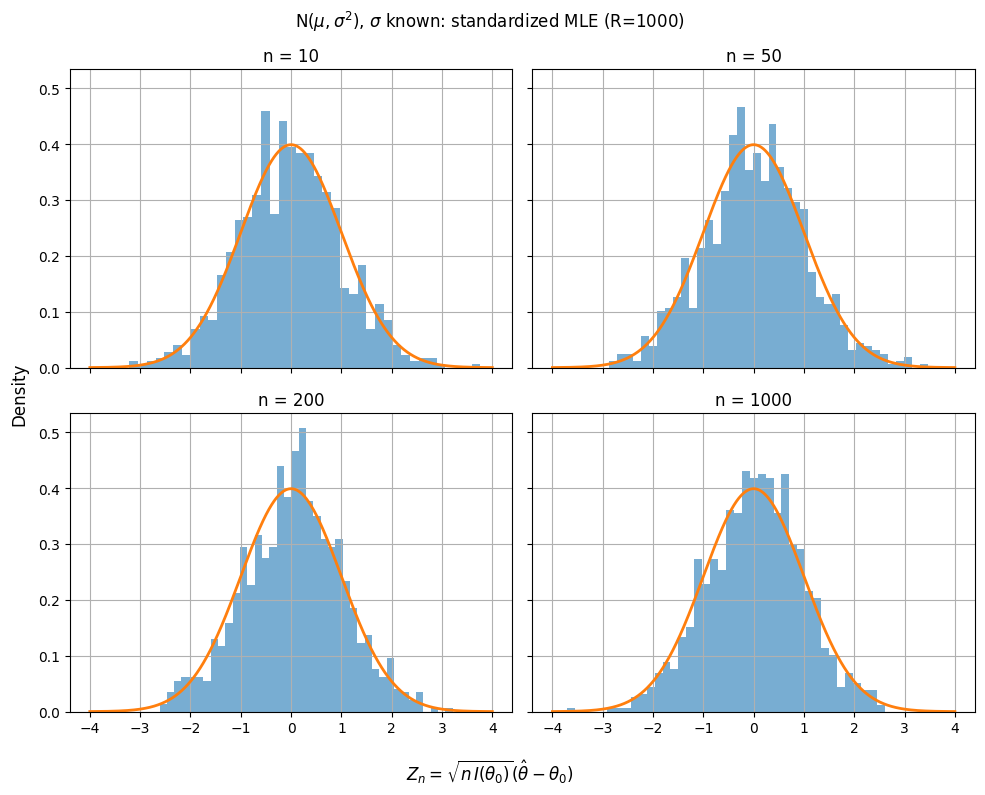

In [2]:
# normal mean, known sigma — standardized MLE draws
def simulate_normal_known_sigma(mu0, sigma, n, R, rng):
    """
    Simulate standardized MLEs for Normal(mu, sigma^2) with sigma known.
    Returns Z_n = sqrt(n) * (mu_hat - mu0) / sigma.

    Parameters:
    ----------
      mu0  : float
             true mean used to generate data
      sigma: float
             known observation standard deviation
      n    : int
             sample size per replication
      R    : int
             number of Monte Carlo replications
      rng  : np.random.Generator
             random generator for reproducibility

    Returns:
    ----------
      Z    : np.ndarray
             vector (length R) of standardized MLE draws
    """
    # draw data matrix shape (R, n)
    X = rng.normal(loc=mu0, scale=sigma, size=(R, n))

    # compute MLE mu_hat = row-wise sample mean
    mu_hat = X.mean(axis=1)

    # compute standardized statistic
    Z = np.sqrt(n) * (mu_hat - mu0) / sigma
    return Z

# run: Normal mean, known sigma
summary_normal = run_and_plot(model_name=r"N($\mu,\sigma^{2}$), $\sigma$ known",
                              generator_fn=simulate_normal_known_sigma,
                              n_list=n_list,
                              R=R,
                              x_plot=x_plot,
                              mu0=0.75,
                              sigma=1.0)


## Bernoulli

Model: $X_1,\dots,X_n \stackrel{\text{iid}}{\sim} \text{Bernoulli}(p)$ with $p\in(0,1)$.

Log-likelihood:
$$
\ell_n(p) = \sum_{i=1}^n [X_i\log p + (1-X_i)\log(1-p)]
$$

Score and observed information:
$$
s_n(p) = \frac{\partial}{\partial p}\ell_n(p)
= \sum_{i=1}^n\left(\frac{X_i}{p} - \frac{1-X_i}{1-p}\right),
\qquad
J_n(p) = -\frac{\partial^2}{\partial p^2}\ell_n(p)
= \sum_{i=1}^n\left(\frac{X_i}{p^2} + \frac{1-X_i}{(1-p)^2}\right)
$$

MLE:
$$
\hat p = \bar X = \frac{1}{n}\sum_{i=1}^n X_i
$$

Fisher information (per observation):
$$
I(p) = \mathbb E_p\!\left[\frac{X}{p^2} + \frac{1-X}{(1-p)^2}\right] = \frac{1}{p(1-p)}
$$

Asymptotics:
$$
\sqrt{n}(\hat p - p_0) \xrightarrow{d} \mathcal N(0,\,p_0(1-p_0)),
\qquad
Z_n = \sqrt{n}\,\frac{\hat p - p_0}{\sqrt{p_0(1-p_0)}} \xrightarrow{d} \mathcal N(0,1)
$$

Notes:
- Small $n$ can show mild skew if $p_0$ is near 0 or 1.
- Variance scales as $p_0(1-p_0)/n$.
- Convergence to normality slows near the boundaries.


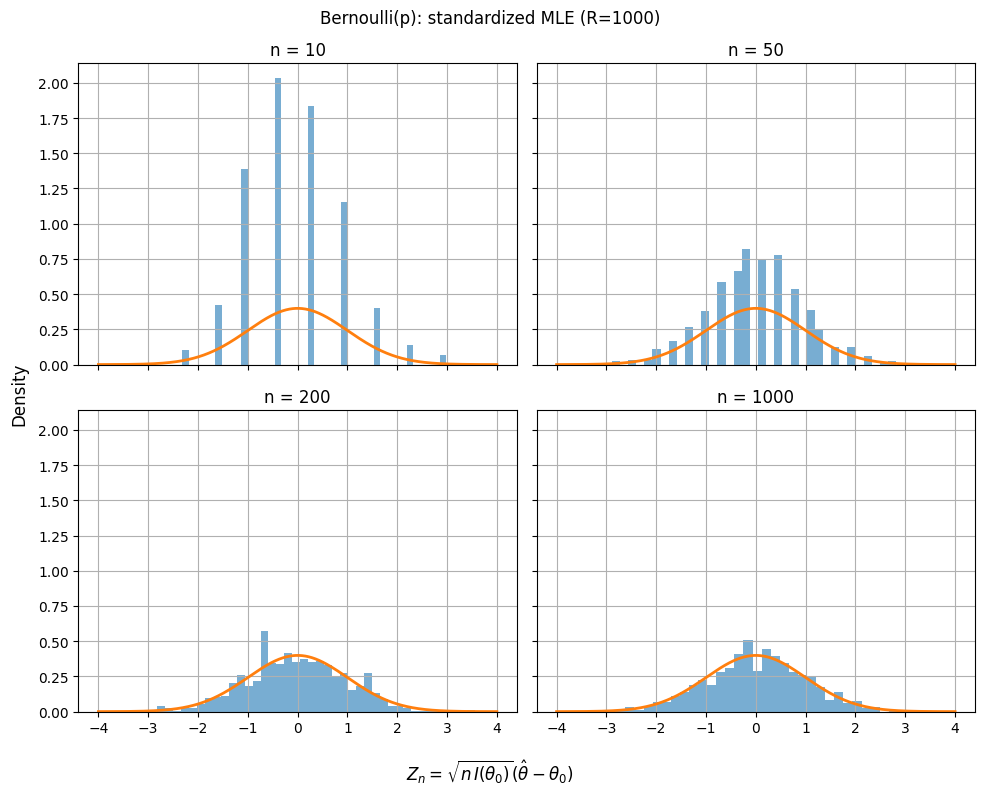

In [3]:
# bernoulli p — standardized MLE draws
def simulate_bernoulli(p0, n, R, rng):
    """
    Simulate standardized MLEs for Bernoulli(p).
    Returns Z_n = sqrt(n) * sqrt(1/[p0(1-p0)]) * (p_hat - p0).

    Parameters:
    ----------
      p0   : float
             true success probability in (0, 1)
      n    : int
             sample size per replication
      R    : int
             number of Monte Carlo replications
      rng  : np.random.Generator
             random generator for reproducibility

    Returns:
    ----------
      Z    : np.ndarray
             vector (length R) of standardized MLE draws
    """
    # draw bernoulli data shape (R, n)
    X = rng.binomial(n=1, p=p0, size=(R, n))

    # compute MLE p_hat = row-wise sample mean
    p_hat = X.mean(axis=1)

    # compute sqrt Fisher info at p0
    sqrtI = 1.0 / np.sqrt(p0 * (1.0 - p0))

    # compute standardized statistic
    Z = np.sqrt(n) * sqrtI * (p_hat - p0)
    return Z


# run: Bernoulli
summary_bern = run_and_plot(model_name="Bernoulli(p)",
                            generator_fn=simulate_bernoulli,
                            n_list=n_list,
                            R=R,
                            x_plot=x_plot,
                            p0=0.35)

## Exponential rate $\lambda$

Model: $X_1,\dots,X_n \stackrel{\text{iid}}{\sim} \text{Exponential}(\lambda)$ with pdf $f(x)=\lambda e^{-\lambda x}$ for $x\ge 0$.

Log-likelihood:
$$
\ell_n(\lambda) = \sum_{i=1}^n (\log\lambda - \lambda X_i)
= n\log\lambda - \lambda\sum_{i=1}^n X_i
$$

Score and observed information:
$$
s_n(\lambda) = \frac{\partial}{\partial\lambda}\ell_n(\lambda)
= \frac{n}{\lambda} - \sum_{i=1}^n X_i,
\qquad
J_n(\lambda) = -\frac{\partial^2}{\partial\lambda^2}\ell_n(\lambda)
= \frac{n}{\lambda^2}
$$

MLE:
$$
\hat\lambda = \frac{1}{\bar X} = \left(\frac{1}{n}\sum_{i=1}^n X_i\right)^{-1}
$$

Fisher information (per observation):
$$
I(\lambda) = \mathbb E_\lambda\!\left[\frac{1}{\lambda^2}\right] = \frac{1}{\lambda^2}
$$

Asymptotics:
$$
\sqrt{n}(\hat\lambda-\lambda_0) \xrightarrow{d} \mathcal N(0,\,\lambda_0^2),
\qquad
Z_n = \sqrt{n}\,\frac{\hat\lambda-\lambda_0}{\lambda_0} \xrightarrow{d} \mathcal N(0,1)
$$

Notes:
- For small $n$, $Z_n$ is right-skewed because $\hat\lambda = 1/\bar X$ is nonlinear.
- Convergence to normality is slower than for the normal mean.
- By $n \ge 200$, the normal approximation becomes visually accurate.


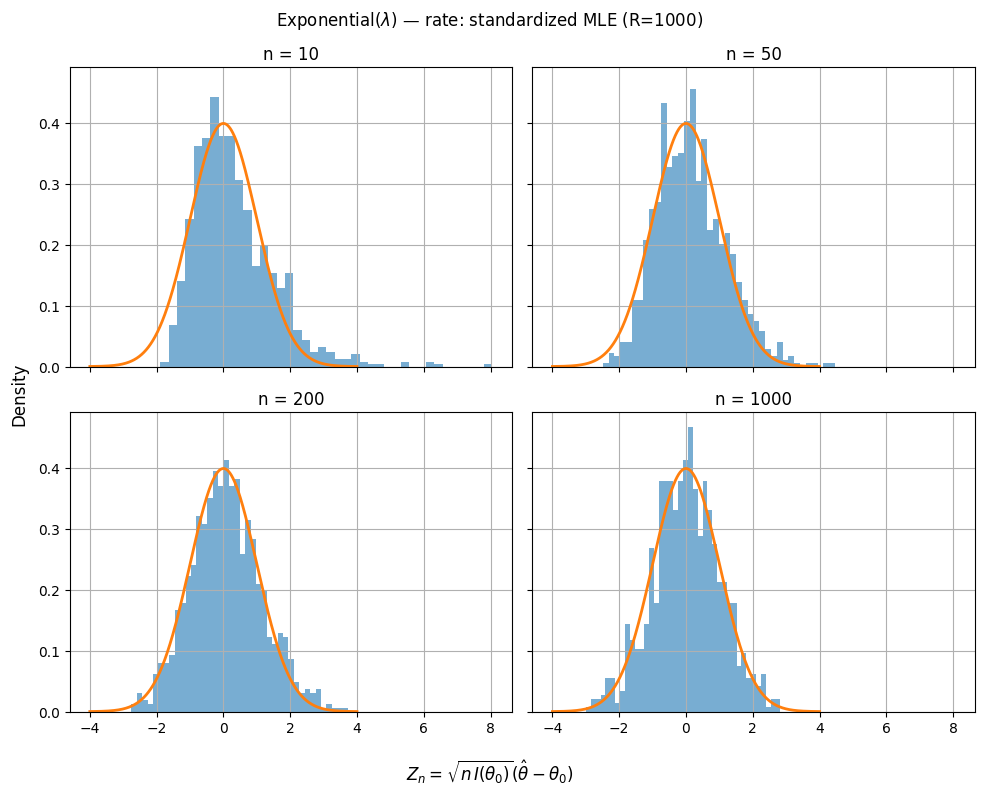

In [4]:
# exponential rate — standardized MLE draws
def simulate_exponential_rate(lam0, n, R, rng):
    """
    Simulate standardized MLEs for Exponential(lam) with rate parameterization.
    Returns Z_n = sqrt(n) * (lam_hat - lam0) / lam0.

    Parameters:
    ----------
      lam0 : float
             true rate (>0) for exponential distribution
      n    : int
             sample size per replication
      R    : int
             number of Monte Carlo replications
      rng  : np.random.Generator
             random generator for reproducibility

    Returns:
    ----------
      Z    : np.ndarray
             vector (length R) of standardized MLE draws
    """
    # draw exponential data (np uses scale = 1/lambda)
    X = rng.exponential(scale=1.0 / lam0, size=(R, n))

    # compute row-wise means
    xbar = X.mean(axis=1)

    # MLE for rate: lam_hat = 1/xbar
    lam_hat = 1.0 / xbar

    # standardized statistic using sqrt(I) = 1/lam0
    Z = np.sqrt(n) * (lam_hat - lam0) / lam0
    return Z

# run: Exponential rate
summary_exp = run_and_plot(model_name=r"Exponential($\lambda$) — rate",
                           generator_fn=simulate_exponential_rate,
                           n_list=n_list,
                           R=R,
                           x_plot=x_plot,
                           lam0=1.7)


## Summary

All three models satisfy
$$
Z_n = \sqrt{n I(\theta_0)}\,(\hat\theta-\theta_0) \Rightarrow \mathcal N(0,1).
$$
Convergence speed differs:
- Normal mean: fastest, perfectly symmetric.
- Bernoulli: depends on $p_0$; slower near 0 or 1.
- Exponential: nonlinear MLE causes skew at small $n$.

In [5]:
# aggregate summaries
summary_all = pd.concat([summary_normal, summary_bern, summary_exp],
                        ignore_index=True).sort_values(["model", "n"])
display(summary_all)

,model,n,mean_Z,sd_Z,excess_kurt_Z
4,Bernoulli(p),10,-0.008619,0.970776,0.161922
5,Bernoulli(p),50,-0.010674,0.949399,0.292209
6,Bernoulli(p),200,-0.026537,0.988388,-0.055654
7,Bernoulli(p),1000,0.020619,1.014468,0.189379
8,Exponential(lambda) — rate,10,0.319545,1.193322,3.972513
9,Exponential(lambda) — rate,50,0.165903,1.044865,0.354267
10,Exponential(lambda) — rate,200,0.101329,1.071189,0.053349
11,Exponential(lambda) — rate,1000,0.013006,1.012703,-0.008425
0,"N(mu,sigma^2), sigma known",10,-0.021624,1.009786,0.162772
1,"N(mu,sigma^2), sigma known",50,0.020141,1.021280,0.095129
